# TDI: da fonte oficial ao Power BI

Demonstracao do ciclo da Taxa de Distorcao Idade-Serie (TDI), de 2007 a 2023, por UF, etapa e rede publica. A saida para o BI e `data/gold/fatos/fato_tdi.parquet`.

## Ciclo

Raw oficial -> auditoria da serie -> Bronze anual -> Silver harmonizada -> fato Gold -> Power BI. A Gold possui o grao `ANO + UF + ETAPA + REDE`; as dimensoes sao compartilhadas com os demais indicadores.

## Criterios de tratamento e linhagem

A Bronze preserva a estrutura fisica de cada planilha anual. Na Silver, o pipeline seleciona somente o ano correspondente, as 27 UFs, `LOCALIZACAO = Total` e o agregado oficial `Publico`/`Publica`. Brasil e regioes sao removidos pela conversao controlada para as siglas das 27 UFs.

`REDE = PUBLICA` e a categoria canonica usada na serie; `REDE_ORIGEM` preserva a grafia efetivamente publicada. Nao e feita media simples entre dependencias administrativas e nao e usado agregado que inclua rede privada. `LOCALIZACAO_ORIGEM`, arquivo, linha e coluna permanecem na Silver como linhagem.

As colunas de cada arquivo sao mapeadas por ano porque os layouts mudam. Uma linha publica-total por UF origina dois registros, um para cada etapa. O total esperado e `17 anos x 27 UFs x 2 etapas = 918`. A Gold seleciona apenas `ANO`, `UF`, `ETAPA`, `REDE` e `TDI`, sem recalcular a taxa.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

DIRETORIO_ATUAL = Path.cwd().resolve()
ROOT = next((p for p in (DIRETORIO_ATUAL, *DIRETORIO_ATUAL.parents) if (p / 'src' / 'pipeline.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Nao foi possivel localizar a raiz do repositorio.')
print(f'Raiz do projeto: {ROOT}')
EXECUTAR_AUDITORIAS = False
EXECUTAR_PIPELINE_INDICADOR = False
pd.set_option('display.max_columns', 30)

Raiz do projeto: C:\portfolio-pipeline-dados-educacionais


In [2]:
AUDITORIAS = [
    'src/auditoria_tdi/inspecionar_tdi.py',
    'src/auditoria_tdi/verificar_serie_publica_tdi.py',
]
ETAPAS = [
    'src/bronze/tdi/ingest_tdi.py',
    'src/bronze/tdi/validar_bronze_tdi.py',
    'src/silver/tdi/transformar_tdi.py',
    'src/silver/tdi/validar_silver_tdi.py',
    'src/gold/tdi/transformar_tdi.py',
    'src/gold/tdi/validar_fato_tdi.py',
]
def executar(scripts):
    for script in scripts:
        print(f'\n>>> {script}')
        subprocess.run([sys.executable, script], cwd=ROOT, check=True)
print('Auditorias:', *AUDITORIAS, sep='\n- ')
print('\nEtapas:', *ETAPAS, sep='\n- ')

Auditorias:
- src/auditoria_tdi/inspecionar_tdi.py
- src/auditoria_tdi/verificar_serie_publica_tdi.py

Etapas:
- src/bronze/tdi/ingest_tdi.py
- src/bronze/tdi/validar_bronze_tdi.py
- src/silver/tdi/transformar_tdi.py
- src/silver/tdi/validar_silver_tdi.py
- src/gold/tdi/transformar_tdi.py
- src/gold/tdi/validar_fato_tdi.py


In [3]:
if EXECUTAR_AUDITORIAS:
    executar(AUDITORIAS)
else:
    print('Auditorias nao executadas.')
if EXECUTAR_PIPELINE_INDICADOR:
    executar(ETAPAS)
else:
    print('Pipeline nao executado; leitura dos artefatos existentes.')

Auditorias nao executadas.
Pipeline nao executado; leitura dos artefatos existentes.


## Evidencias por camada

A Raw e inventariada sem alteracao. As camadas derivadas sao abertas para comparar volume, esquema e amostras.

In [4]:
raw = sorted((ROOT / 'data/raw/tdi').glob('*'))
bronze = sorted((ROOT / 'data/bronze/tdi').glob('*.parquet'))
silver_path = ROOT / 'data/silver/tdi/tdi_2007_2023.parquet'
gold_path = ROOT / 'data/gold/fatos/fato_tdi.parquet'
pd.DataFrame({'camada':['Raw','Bronze','Silver','Gold'], 'arquivos':[len(raw),len(bronze),int(silver_path.exists()),int(gold_path.exists())], 'destino':[str(ROOT/'data/raw/tdi'),str(ROOT/'data/bronze/tdi'),str(silver_path),str(gold_path)]})

,camada,arquivos,destino
0,Raw,17,C:\portfolio-pipeline-dados-educacionais\data\...
1,Bronze,17,C:\portfolio-pipeline-dados-educacionais\data\...
2,Silver,1,C:\portfolio-pipeline-dados-educacionais\data\...
3,Gold,1,C:\portfolio-pipeline-dados-educacionais\data\...


In [5]:
amostra_bronze = pd.read_parquet(bronze[0])
silver = pd.read_parquet(silver_path)
gold = pd.read_parquet(gold_path)
display(amostra_bronze.head(3), silver.head(3), gold.head(3))
pd.DataFrame({'camada':['Bronze (um ano)','Silver','Gold'], 'linhas':[len(amostra_bronze),len(silver),len(gold)], 'colunas':[len(amostra_bronze.columns),len(silver.columns),len(gold.columns)]})

,_fonte,_sha256_arquivo,_arquivo_origem,_aba_origem,_ano_referencia,_indice_cabecalho_origem,_linha_origem,col_001,col_002,col_003,col_004,col_005,col_006,col_007,col_008,col_009,col_010,col_011,col_012,col_013,col_014,col_015,col_016,col_017,col_018,col_019,col_020,col_021,col_022
0,TDI,2428b12279d823737f9ed4652540ef4dbe9115a834e615...,TDI UFS 2007.xls,POR UF,2007,5,1,<NA>,Ministério da Educação,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,TDI,2428b12279d823737f9ed4652540ef4dbe9115a834e615...,TDI UFS 2007.xls,POR UF,2007,5,2,<NA>,Instituto Nacional de Es...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,TDI,2428b12279d823737f9ed4652540ef4dbe9115a834e615...,TDI UFS 2007.xls,POR UF,2007,5,4,Taxa...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


,ANO,UF,ETAPA,REDE,TDI,REDE_ORIGEM,LOCALIZACAO_ORIGEM,ARQUIVO_ORIGEM,LINHA_ORIGEM_BRONZE,COLUNA_ORIGEM
0,2007,AC,ANOS_INICIAIS,PUBLICA,35.9,Publico,Total,TDI UFS 2007.xls,34,col_015
1,2007,AC,ANOS_FINAIS,PUBLICA,37.3,Publico,Total,TDI UFS 2007.xls,34,col_016
2,2007,AL,ANOS_INICIAIS,PUBLICA,38.3,Publico,Total,TDI UFS 2007.xls,243,col_015


,ANO,UF,ETAPA,REDE,TDI
0,2007,AC,ANOS_FINAIS,PUBLICA,37.3
1,2007,AC,ANOS_INICIAIS,PUBLICA,35.9
2,2007,AL,ANOS_FINAIS,PUBLICA,61.4


,camada,linhas,colunas
0,Bronze (um ano),478,29
1,Silver,918,10
2,Gold,918,5


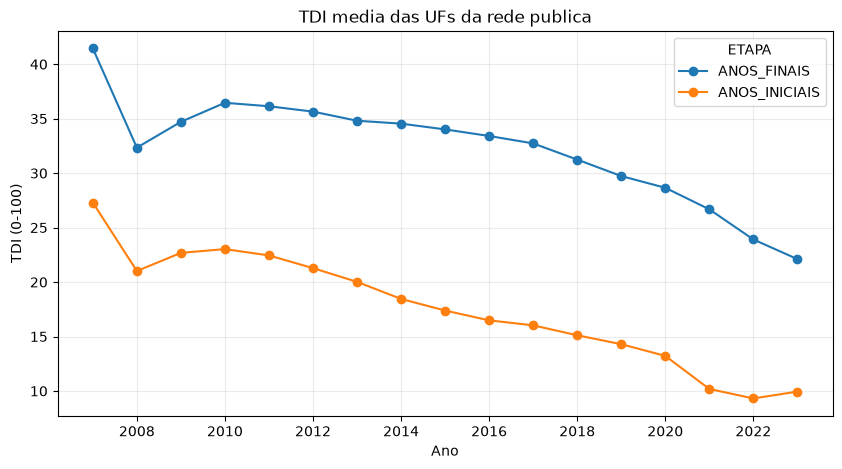

In [6]:
resumo = gold.groupby(['ANO','ETAPA'], as_index=False)['TDI'].mean()
grafico = resumo.pivot(index='ANO', columns='ETAPA', values='TDI')
ax = grafico.plot(figsize=(10,5), marker='o')
ax.set(title='TDI media das UFs da rede publica', xlabel='Ano', ylabel='TDI (0-100)')
ax.grid(alpha=0.25)
plt.show()

## Disponibilizacao para o BI

`fato_tdi.parquet` e consumida com `DIM_UF`, `DIM_TEMPO` e `DIM_ETAPA`. A validacao completa do conjunto ocorre por `python src/pipeline.py full`. A visualizacao e descritiva e nao estabelece relacao causal.